#**Gastrointestinal Disease Mapping Using AI**
##**Objective 3: Autoencoder**
---
> <p align = "justify">This objective aims to apply the knoweledge gained from the previous objectives and create an autoencoder, first capable of recontructing the input image and then able to map concerning reagions of a given image. The autoencoder will be one of the neural nets of the GAN, hence being used
---


###1. Imports

In [1]:
import tensorflow as tf
import os, cv2, math, random, PIL, PIL.Image,pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import sklearn
from tqdm import tqdm
from tensorflow import keras
from tensorflow.keras import layers,losses
from tensorflow.keras.layers import Dense,Flatten,Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Sequential, Model
#from tensorboard.plugins.hparams import api as hp
from sklearn.model_selection import train_test_split, cross_val_score, KFold
#from sklearn.metrics import plot_confusion_matrix, ConfusionMatrixDisplay, confusion_matrix,accuracy_score, precision_score, recall_score

print("TensorFlow Version Used: ",tf.__version__)

TensorFlow Version Used:  2.12.0


###2. Data Loading

In [2]:
from google.colab import drive
# Mount Google Drive to access dataset
drive.mount('/content/gdrive/')

# Define the path to the dataset
data_dir = '/content/gdrive/MyDrive/Colab_Notebooks/kid-dataset-original'

# Load the dataset
data = []
labels = []
for class_dir in os.listdir(data_dir):
    if not os.path.isdir(os.path.join(data_dir, class_dir)):
        continue
    for filename in os.listdir(os.path.join(data_dir, class_dir)):
        img = tf.keras.preprocessing.image.load_img(os.path.join(data_dir, class_dir, filename), target_size=(360, 360))
        img = tf.keras.preprocessing.image.img_to_array(img)
        data.append(img)
        labels.append(class_dir)

Mounted at /content/gdrive/


###3. Pre-Processing and Data Split

In [3]:
# Convert data and labels to arrays
data = np.array(data)
labels = np.array(labels)

# Normalize data
data = data / 255.0

#Print Unique Labels for Quick Quality check
print(sklearn.utils.multiclass.unique_labels(labels))

# Split the dataset into training and validation sets
train_data, val_data, train_labels, val_labels = train_test_split(data, labels, test_size=0.2, stratify=labels)

['ampulla-of-vater' 'inflammatory' 'normal-colon' 'normal-esophagus'
 'normal-small-bowel' 'normal-stomach' 'polypoids' 'vascular']


###4. Train and Validation Sets Image Count Check

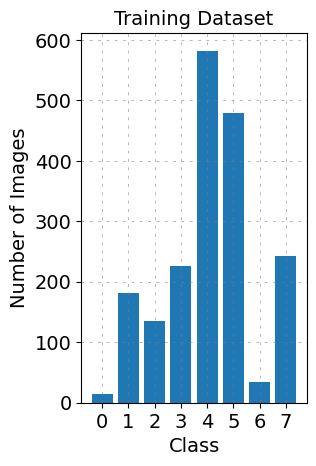

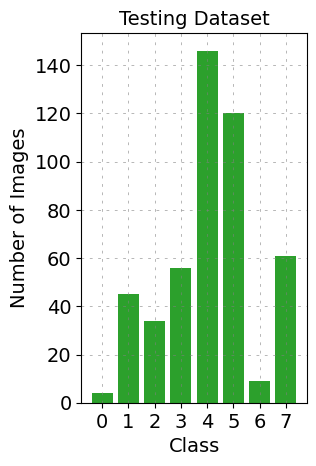

In [7]:
# Define the order of the labels
label_order = ['ampulla-of-vater', 'inflammatory', 'normal-colon', 'normal-esophagus', 'normal-small-bowel', 'normal-stomach', 'polypoids', 'vascular']

# Count the number of images for each label in train data
train_counts = {label: 0 for label in label_order}
for label in train_labels:
    train_counts[label] += 1

# Count the number of images for each label in validation data
val_counts = {label: 0 for label in label_order}
for label in val_labels:
    val_counts[label] += 1

# Plot bar chart for train data
plt.subplot(1, 2, 1)
plt.bar(train_counts.keys(), train_counts.values(),color='C0')
plt.xticks([0,1,2,3,4,5,6,7],['0','1','2','3','4','5','6','7'],fontsize=14)
plt.title ('Training Dataset',fontsize=14)
plt.ylabel('Number of Images',fontsize=14)
plt.xlabel('Class', fontsize=14)
plt.yticks(fontsize=14)
plt.grid (True, color = "grey", linewidth = "0.4", linestyle = (0,(5,10)))
plt.show()

# Plot bar chart for validation data
plt.subplot(1,2,2)
plt.bar(val_counts.keys(), val_counts.values(),color='C2')
plt.xticks([0,1,2,3,4,5,6,7],['0','1','2','3','4','5','6','7'],fontsize=14)
plt.title ('Testing Dataset',fontsize=14)
plt.ylabel('Number of Images',fontsize=14)
plt.xlabel('Class', fontsize=14)
plt.yticks(fontsize=14)
plt.grid (True, color = "grey", linewidth = "0.4", linestyle = (0,(5,10)))
plt.show()


###5. Autoencoder Model

In [ ]:
encoder_input = tf.keras.layers.Input(shape=(360, 360, 3))
encoder1 = (Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(360, 360, 3)))(encoder_input)
encoder2 = (MaxPooling2D((2, 2), padding='same'))(encoder1)
encoder3 = (Conv2D(64, (3, 3), activation='relu', padding='same'))(encoder2)
encoder4 = (MaxPooling2D((2, 2), padding='same'))(encoder3)
encoder5 = (Conv2D(128, (3, 3), activation='relu', padding='same'))(encoder4)
encoder6 = (MaxPooling2D((2, 2), padding='same'))(encoder5)
encoder7 = (Conv2D(256, (3, 3), activation='relu', padding='same'))(encoder6)
encoder8 = (MaxPooling2D((3, 3), padding='same'))(encoder7)
#encoder = tf.keras.models.Model(inputs=encoder_input, outputs=encoder8)

#decoder_input = tf.keras.layers.Input(shape=(15, 15, 256))
decoder1 = (Conv2D(256, (3, 3), activation='relu', padding='same'))(encoder8)
decoder2 = (UpSampling2D((3, 3)))(decoder1)
decoder3 = (Conv2D(128, (3, 3), activation='relu', padding='same'))(decoder2)
decoder4 = (UpSampling2D((2, 2)))(decoder3)
decoder5 = (Conv2D(64, (3, 3), activation='relu', padding='same'))(decoder4)
decoder6 = (UpSampling2D((2, 2)))(decoder5)
decoder7 = (Conv2D(32, (3, 3), activation='relu', padding='same'))(decoder6)
decoder8 = (UpSampling2D((2, 2)))(decoder7)
decoder9 = (Conv2D(3, (3, 3), activation='sigmoid', padding='same'))(decoder8)
#decoder = tf.keras.models.Model(inputs=decoder_input, outputs=decoder9)

#autoencoder_output = decoder(encoder(encoder_input))
autoencoder = tf.keras.models.Model(inputs=encoder_input, outputs=decoder9)

# Compile the model
autoencoder.compile(optimizer='adam', loss='MSE')

#Model Summary
autoencoder.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 360, 360, 3)]     0         
                                                                 
 model (Functional)          (None, 15, 15, 256)       388416    
                                                                 
 model_1 (Functional)        (None, 360, 360, 3)       978243    
                                                                 
Total params: 1,366,659
Trainable params: 1,366,659
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model9 = Sequential()
# Encoder layers
model9.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(360, 360, 3)))
model9.add(MaxPooling2D((2, 2), padding='same'))
model9.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model9.add(MaxPooling2D((2, 2), padding='same'))
model9.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model9.add(MaxPooling2D((2, 2), padding='same'))

#Latent Space
model9.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model9.add(MaxPooling2D((3, 3), padding='same'))

#model9.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
#model9.add(MaxPooling2D((3, 3), padding='same'))

#model9.add(Conv2D(1024, (3, 3), activation='relu', padding='same'))
#model9.add(MaxPooling2D((5, 5), padding='same'))#1

#model9.add(Conv2D(1024, (3, 3), activation='relu', padding='same'))
#model9.add(UpSampling2D((5, 5)))

#model9.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
#model9.add(UpSampling2D((3, 3)))

model9.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model9.add(UpSampling2D((3, 3)))

# Decoder layers
model9.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model9.add(UpSampling2D((2, 2)))
model9.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model9.add(UpSampling2D((2, 2)))
model9.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model9.add(UpSampling2D((2, 2)))
model9.add(Conv2D(3, (3, 3), activation='sigmoid', padding='same'))


model9.summary()

model9.compile(optimizer='adam', loss='MSE')

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 360, 360, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 180, 180, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 180, 180, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 90, 90, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 90, 90, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 45, 45, 128)      0

In [ ]:
# Train the autoencoder
history = model9.fit(train_data, train_data, epochs=25, batch_size=32, validation_data=(val_data, val_data))

Epoch 1/25
60/60 [==============================] - 20s 118ms/step - loss: 0.0356 - val_loss: 0.0076
Epoch 2/25
60/60 [==============================] - 5s 79ms/step - loss: 0.0051 - val_loss: 0.0032
Epoch 3/25
60/60 [==============================] - 5s 79ms/step - loss: 0.0034 - val_loss: 0.0028
Epoch 4/25
60/60 [==============================] - 5s 79ms/step - loss: 0.0023 - val_loss: 0.0021
Epoch 5/25
60/60 [==============================] - 5s 79ms/step - loss: 0.0020 - val_loss: 0.0023
Epoch 6/25
60/60 [==============================] - 5s 79ms/step - loss: 0.0019 - val_loss: 0.0016
Epoch 7/25
60/60 [==============================] - 5s 78ms/step - loss: 0.0021 - val_loss: 0.0042
Epoch 8/25
60/60 [==============================] - 5s 78ms/step - loss: 0.0019 - val_loss: 0.0013
Epoch 9/25
60/60 [==============================] - 5s 78ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 10/25
60/60 [==============================] - 5s 80ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 1

In [ ]:
# save the weights
encoder.save('/content/gdrive/MyDrive/Colab_Notebooks/encoder1.h5')

###6. Performance Assessment

####6.1. Original and Reconstructed Images Comparisson 

1/1 [==============================] - 0s 329ms/step


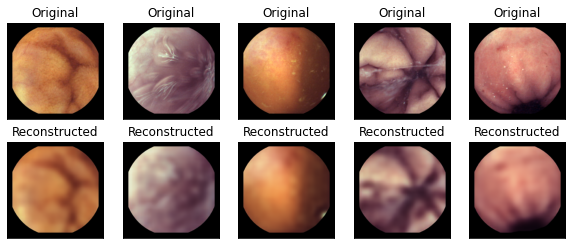

In [ ]:
# select some random images to display
n = 5
samples = np.random.randint(val_data.shape[0], size=n)

# predict the reconstructed images
reconstructed = model9.predict(val_data[samples])

# display the original images and the corresponding reconstructed images
plt.figure(figsize=(10, 4))
for i in range(n):
    # display original image
    ax = plt.subplot(2, n, i+1)
    plt.imshow(val_data[samples[i]])
    plt.title("Original")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstructed image
    ax = plt.subplot(2, n, i+n+1)
    plt.imshow(reconstructed[i])
    plt.title("Reconstructed")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

####6.2. Training and Validation Loss Plots

In [ ]:
# Evaluate the performance of the autoencoder on the validation set
reconstruction_loss = model9.evaluate(val_data, val_data)
print("Validation Reconstruction Loss: ", round(reconstruction_loss,4))

15/15 [==============================] - 1s 39ms/step - loss: 8.5934e-04
Validation Reconstruction Loss:  0.0009


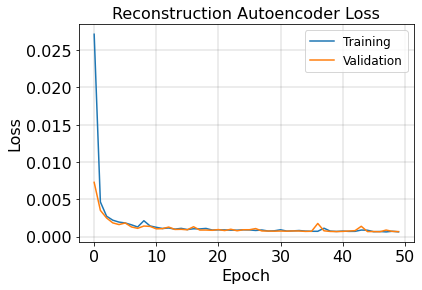

In [ ]:
# Plot the training and validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.grid(True, color = "grey", linewidth = "0.3", linestyle = "solid")
plt.title('Reconstruction Autoencoder Loss',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.xlabel('Epoch',fontsize=16)
plt.legend(['Training', 'Validation'], loc='upper right',fontsize=12)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
#plt.axis(ymin=0,ymax=0.01)
plt.show()

###7. 3D Model Visualization

In [ ]:
#pip install visualkeras
!pip install git+https://github.com/paulgavrikov/visualkeras --upgrade

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Cloning https://github.com/paulgavrikov/visualkeras to /tmp/pip-req-build-qy4_qh_x
  Running command git clone --filter=blob:none --quiet https://github.com/paulgavrikov/visualkeras /tmp/pip-req-build-qy4_qh_x
  Resolved https://github.com/paulgavrikov/visualkeras to commit d7111d3471173c0b16853a6ce5e4cc645498380a
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 992.0/992.0 KB 41.1 MB/s eta 0:00:00
  Created wheel for visualkeras: filename=visualkeras-0.0.2-py3-none-any.whl size=13450 sha256=bb6768b46e1f18ca73af4d357d48796e16a8e3a4925810ed83042f7ee4a8ff57
  Stored in directory: /tmp/pip-ephem-wheel-cache-m3utru3q/wheels/3a/96/3c/e6bcf58185d2017dc7b072e5794e6b1dd034d1bdb7d15e2463
Successfully built visualkeras


In [ ]:
#imports
import visualkeras
from PIL import ImageFont, ImageDraw, Image
from collections import defaultdict

#Define Font type and Font size
font = ImageFont.truetype("arial.ttf", 25)

#Create Tailored Color Map (the buil-in one is better)
#color_map = defaultdict(dict)
#color_map[Conv2D]['fill'] = 'lightblue'
#color_map[MaxPooling2D]['fill'] = 'coral'
#color_map[UpSampling2D]['fill'] = 'lightblue'


#visualize and save the model
visualkeras.layered_view(model9, legend=True, font=font, draw_volume=True,spacing=20,scale_xy=1, scale_z=1, max_z=30, color_map = color_map, to_file='autoencoder.png') 

OSError: ignored